# EDA: what does the data look like, and can we trust residuals from a healthy baseline?

This notebook works through the engineering checklist against the release
data: how much coverage each fault and load bin has, how far load alone
moves each channel compared with a fault, what each fault looks like around
its switch-on, and two puzzles (cavitation's weak mean shift, the injector
and test-day runs). Findings are filled in once every part is done.

**Main findings:** (filled in once T-006 is done).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from keyframe import eda, load, paths

paths.FIGURES.mkdir(parents=True, exist_ok=True)
paths.RESULTS.mkdir(parents=True, exist_ok=True)

clean_path = paths.PROCESSED / "clean.parquet"
full_table = pd.read_parquet(clean_path) if clean_path.exists() else load.load_all(paths.RAW)

FAULT_RUNS = sorted(full_table.loc[full_table["fault_type"] != "Normal", "run"].unique())

# Channels named across the engineering checklist's "Expected" tables, shared
# by every fault so the load-vs-fault comparison in this notebook has a
# common basis.
CHECKLIST_CHANNELS = [
    "Charge Air IC Air Temp. In",
    "Charge Air IC Air Temp. Out",
    "Charge Air Press.",
    "No.1 Exh.Gas Temp.",
    "No.2 Exh.Gas Temp.",
    "No.3 Exh.Gas Temp.",
    "Exh.Gas Temp. Turbine In",
    "Exh.Gas Temp. Turbine Out",
    "Max. In-Cylinder Press. No.1",
    "TCH Power",
    "Exh. Gas Mass Flow",
    "Fresh Cooling Water Press.",
    "Engine Cooling water flow",
    "Loss with cooling water",
]

## How much coverage does each fault have, per load bin?

Rows per fault type and load bin. The leave-one-load-out (LOLO) splits
train on three load bins and test on the fourth: a fold can only be scored
on a class that has rows at the held-out load.

In [2]:
coverage = (
    full_table[full_table["fault_type"] != "Normal"]
    .groupby(["fault_type", "load_bin"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)
coverage.to_csv(paths.RESULTS / "01_coverage.csv")
coverage

load_bin,40,60,75,85
fault_type,,,,
AC,4678,6698,6354,5801
AF,4820,6819,5918,6398
CW,0,5845,0,6263
INJ,1596,2338,61,2497
TD,6397,4905,0,5289


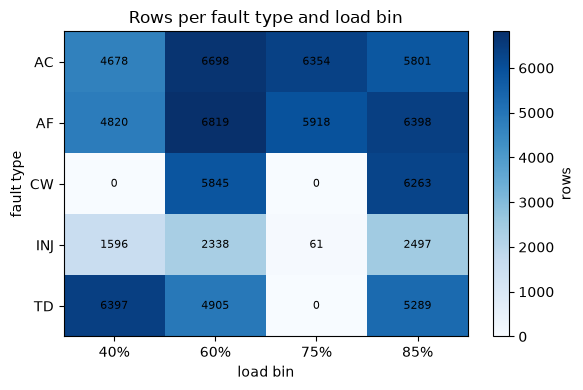

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(coverage.to_numpy(), cmap="Blues", aspect="auto")
ax.set_xticks(range(len(coverage.columns)))
ax.set_xticklabels([f"{c}%" for c in coverage.columns])
ax.set_yticks(range(len(coverage.index)))
ax.set_yticklabels(coverage.index)
ax.set_xlabel("load bin")
ax.set_ylabel("fault type")
ax.set_title("Rows per fault type and load bin")
for i in range(coverage.shape[0]):
    for j in range(coverage.shape[1]):
        ax.text(j, i, coverage.iat[i, j], ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, label="rows")
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_coverage.png", dpi=150)
plt.show()

Each LOLO fold holds out one load bin and trains on the other three, so a
fold can only be scored on classes present at its held-out load. The 40%,
60% and 85% folds see all five fault types; the 75% fold has no cavitation
(CW) or turbine degradation (TD) rows, so those two classes never appear in
a 75%-held-out fold's scores.

## How far does load alone move each channel, compared with a fault?

For each checklist channel: the spread of the healthy (reference) mean
across load bins, standardised by the reference channel's own std, against
the largest standardised fault shift seen for that channel across all fault
runs. If load moves a channel as much as a fault does, a raw threshold on
that channel cannot tell them apart; that is the case for a healthy-engine
residual model rather than raw sensor thresholds.

In [4]:
reference = full_table[full_table["run"] == "Reference_Data"]

fault_shift_frames = []
for run in FAULT_RUNS:
    shift_table = eda.fault_shift(full_table, run, CHECKLIST_CHANNELS)
    shift_table.insert(0, "run", run)
    fault_shift_frames.append(shift_table)
fault_shifts = pd.concat(fault_shift_frames, ignore_index=True)
fault_shifts.to_csv(paths.RESULTS / "01_fault_shifts.csv", index=False)
fault_shifts.head()

,run,channel,healthy_mean,healthy_std,faulty_mean,faulty_std,shift,std_ratio,last30_mean,last30_shift
0,AC_Fouling_40_Load,Charge Air IC Air Temp. In,48.118952,4.949872,46.348909,0.688995,-0.357594,0.139195,47.030735,-0.219847
1,AC_Fouling_40_Load,Charge Air IC Air Temp. Out,33.438928,2.584993,37.468641,4.164918,1.558888,1.611191,41.283759,3.034759
2,AC_Fouling_40_Load,Charge Air Press.,0.216281,0.019625,0.202753,0.001681,-0.689322,0.085677,0.203921,-0.629816
3,AC_Fouling_40_Load,No.1 Exh.Gas Temp.,381.141421,9.522306,382.888606,3.841454,0.183483,0.403416,387.458985,0.663449
4,AC_Fouling_40_Load,No.2 Exh.Gas Temp.,384.960746,11.574761,390.454536,5.366429,0.474635,0.463632,396.356411,0.984527


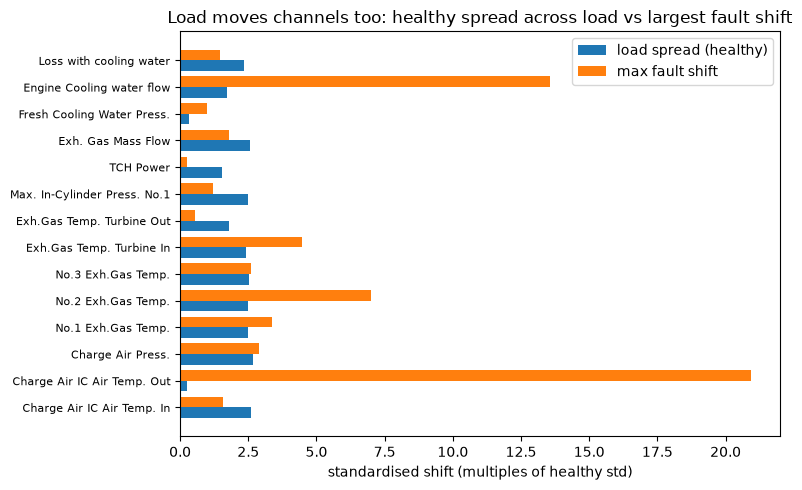

In [5]:
load_spread = {}
for channel in CHECKLIST_CHANNELS:
    by_bin = reference.groupby("load_bin")[channel].mean()
    load_spread[channel] = (by_bin.max() - by_bin.min()) / reference[channel].std()

max_fault_shift = fault_shifts.groupby("channel")["shift"].apply(lambda s: s.abs().max())

comparison = pd.DataFrame(
    {
        "load_spread": pd.Series(load_spread),
        "max_fault_shift": max_fault_shift,
    }
).loc[CHECKLIST_CHANNELS]

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(comparison))
ax.barh(y - 0.2, comparison["load_spread"], height=0.4, label="load spread (healthy)")
ax.barh(y + 0.2, comparison["max_fault_shift"], height=0.4, label="max fault shift")
ax.set_yticks(y)
ax.set_yticklabels(comparison.index, fontsize=8)
ax.set_xlabel("standardised shift (multiples of healthy std)")
ax.set_title("Load moves channels too: healthy spread across load vs largest fault shift")
ax.legend()
fig.tight_layout()
fig.savefig(paths.FIGURES / "01_load_vs_fault_shift.png", dpi=150)
plt.show()